In [1]:
#dataframes
import pandas as pd
import h5py

#suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.TimeSeries = pd.Series 

#math
import numpy as np
import math as m
from scipy.spatial.distance import cdist
from scipy import signal

#plots
import pylab as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import colors
import matplotlib
from figurefirst import FigureLayout,mpl_functions
import figurefirst
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import make_axes_locatable # for colorbar
import seaborn as sns

sns.set_style("whitegrid")
import figurefirst as fifi
from IPython.display import display,SVG

#misc
import time
np.set_printoptions(suppress=True)
import fly_plot_lib.plot as fpl
FS=7

In [6]:
lws=pd.read_hdf('~/DataAnalysis/Figure/review/LWS_Threshold_Analysis.h5')
hws=pd.read_hdf('~/DataAnalysis/Figure/review/HWS_Threshold_Analysis.h5')
forest=pd.read_hdf('~/DataAnalysis/Figure/review/Forest_Threshold_Analysis.h5')

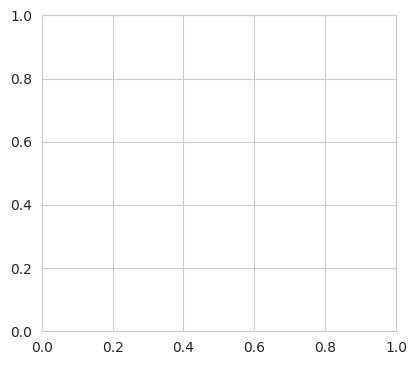

In [39]:
layout = fifi.svg_to_axes.FigureLayout('../../../../Figure/review/thresholdAnalysis.svg',
                                           autogenlayers=True, make_mplfigures=True, hide_layers=[])

In [40]:
ax=layout.axes[('fig','ax')]

lw=0.5
msize=3


ax.plot(hws.threshold,hws.rsquared,c='b',label='HWS', linewidth=lw,rasterized=True)
ax.plot(hws.threshold,hws.rsquared,'o',c='b',markerfacecolor="None", markeredgecolor='b', markersize=msize,rasterized=True)

ax.plot(lws.threshold,lws.rsquared,c='g',label='LWS', linewidth=lw,rasterized=True)
ax.plot(lws.threshold,lws.rsquared,'o',c='g', markerfacecolor="None", markeredgecolor='g', markersize=msize,rasterized=True)

ax.plot(forest.threshold,forest.rsquared,c='purple',label='Forest', linewidth=lw,rasterized=True)
ax.plot(forest.threshold,forest.rsquared,'o',c='purple', markerfacecolor="None", markeredgecolor='purple', markersize=msize,rasterized=True)

ax.grid(False)
ax.set_rasterization_zorder(-20)

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[1,2,4,6,8],
                            yticks = [0,1],
                            linewidth=0.5)
ax.set_xticklabels([1,2,4,6,8])
# ax.set_yticklabels([])

ax.set_ylabel('$R^2$',rotation=0)
ax.yaxis.set_label_coords(-0.04, 0.5)

ax.set_xlabel('Odor Threshold, a.u.')
ax.xaxis.set_label_coords(0.5, -.1)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig'], 'fig', cleartarget=True)
layout.write_svg('../../../../Figure/review/thresholdAnalysis.svg')